# Aula prática — Planck 143 GHz e corte galáctico

FITS -> HEALPix -> degradação -> coordenadas galácticas -> máscara -> f_sky

**Objetivo:** trabalhar com um mapa real do Planck em 143 GHz: ler o FITS, interpretar
NSIDE, degradar a resolução, relacionar pixels com direções no céu e construir um corte
galáctico simples.

> A máscara desta aula é **didática** e não substitui as máscaras científicas completas
> do Planck.

**Nota sobre os dados:** a Seção 1 baixa o arquivo real do Planck (143 GHz, NSIDE=2048,
~600 MB) do Planck Legacy Archive — é o fluxo recomendado, mas o download pode ser lento
dependendo da sua conexão. Para este notebook rodar rápido em qualquer máquina, as seções
seguintes usam por padrão um mapa real menor já incluído no repositório (WMAP 9 anos,
NSIDE 256) — é dado real de outra sonda da CMB, não uma simulação. Se você baixar o
arquivo do Planck, troque `ARQUIVO_MAPA` para `ARQUIVO_PLANCK` logo depois da Seção 1 e o
resto do notebook funciona igual (mesma API do healpy para qualquer mapa HEALPix real).


## 1. Preparar o ambiente

Importa healpy, NumPy e Matplotlib. Antes de ler o mapa, confirma que o Python consegue
localizar o arquivo FITS na pasta de trabalho.


In [1]:
import os
import urllib.request

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

### Baixar o mapa no Planck Legacy Archive (opcional)

- **Arquivo:** `HFI_SkyMap_143-field-IQU_2048_R3.00_full.fits`
- **Fonte:** [Planck Legacy Archive](https://pla.esac.esa.int) — Data Release 3 (PR3) → HFI → Full Sky Maps
- **Frequência:** 143 GHz · **NSIDE:** 2048 · **Campos:** I, Q, U (usaremos I = temperatura)
- **Unidades:** K_CMB

O arquivo tem cerca de 600 MB. O download pode levar vários minutos dependendo da conexão.


In [2]:
ARQUIVO_PLANCK = "HFI_SkyMap_143-field-IQU_2048_R3.00_full.fits"
URL_PLANCK = (
    "https://pla.esac.esa.int/pla/aio/product-action"
    "?MAP.MAP_ID=HFI_SkyMap_143-field-IQU_2048_R3.00_full.fits"
)

if not os.path.exists(ARQUIVO_PLANCK):
    print("Arquivo do Planck nao encontrado localmente.")
    print("Para baixar, descomente as duas linhas abaixo (pode levar varios minutos):")
    print("  urllib.request.urlretrieve(URL_PLANCK, ARQUIVO_PLANCK)")
else:
    print(f"Arquivo do Planck encontrado: {ARQUIVO_PLANCK}")

Arquivo do Planck nao encontrado localmente.
Para baixar, descomente as duas linhas abaixo (pode levar varios minutos):
  urllib.request.urlretrieve(URL_PLANCK, ARQUIVO_PLANCK)


In [3]:
CAMINHO_REPO_DADOS = os.path.join("..", "simulacoes", "dados")
ARQUIVO_WMAP = os.path.join(CAMINHO_REPO_DADOS, "wmap9_ilc_nside256_uK.fits")

# Troque para ARQUIVO_PLANCK se voce baixou o arquivo do Planck acima.
ARQUIVO_MAPA = ARQUIVO_WMAP
JA_EM_MICROKELVIN = True  # o arquivo do WMAP no repo ja esta em uK; o do Planck vem em K

assert os.path.exists(ARQUIVO_MAPA), f"Arquivo nao encontrado: {ARQUIVO_MAPA}"
print(f"Usando: {ARQUIVO_MAPA}")

Usando: ../simulacoes/dados/wmap9_ilc_nside256_uK.fits


## 2. Ler o mapa FITS

`hp.read_map` lê o campo de temperatura e o cabeçalho. Um mapa HEALPix é armazenado como
um vetor: cada posição corresponde a um pixel específico da esfera celeste.


In [4]:
mapa, header = hp.read_map(ARQUIVO_MAPA, field=0, h=True)
print(f"Numero total de pixels: {len(mapa):,}")
print(f"Unidade (do cabecalho): {dict(header).get('TUNIT1', 'nao informada')}")

Numero total de pixels: 786,432
Unidade (do cabecalho): nao informada


## 3. Visualizar o mapa

Mostra o mapa em Mollweide, em coordenadas galácticas (`coord="G"`). Os limites de cor
(`min`/`max`) usam um limite simétrico em torno de zero (±300 µK) — alterar a escala de
cores **não** altera os dados, só a visualização.


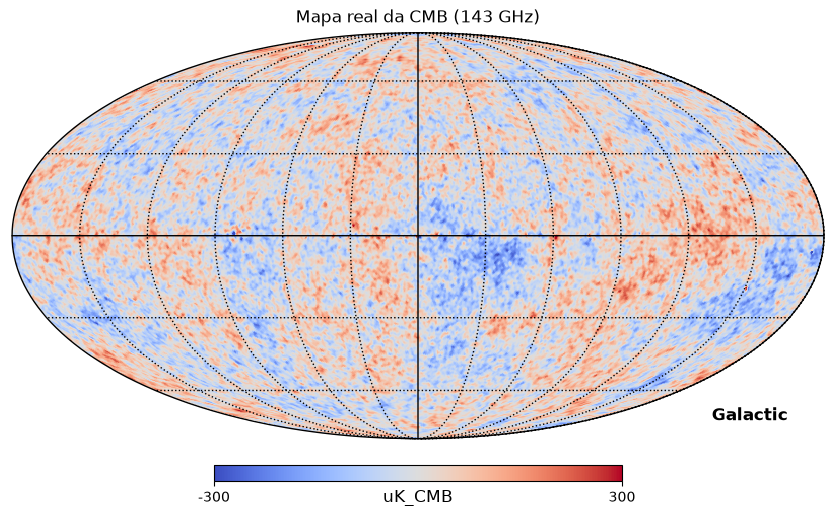

In [5]:
mapa_uK = mapa if JA_EM_MICROKELVIN else mapa * 1e6  # K_CMB -> uK_CMB

hp.mollview(
    mapa_uK,
    coord="G",
    min=-300,
    max=300,
    cmap="coolwarm",
    title="Mapa real da CMB (143 GHz)",
    unit="uK_CMB",
)
hp.graticule()
plt.show()

## 4. Verificar a resolução HEALPix

Confirma o NSIDE do mapa original e a relação:

$$N_{pix} = 12\,N_{side}^2$$


In [6]:
nside = hp.get_nside(mapa)
npix = hp.nside2npix(nside)
print(f"NSIDE = {nside}")
print(f"Npix  = 12 x {nside}^2 = {npix:,}")
assert npix == 12 * nside**2

NSIDE = 256
Npix  = 12 x 256^2 = 786,432


## 5. Degradar a resolução

`hp.ud_grade` representa o mesmo céu com uma pixelização menos fina. Degradar **não**
muda a região do céu observada, só a resolução da pixelização. (Na aula original, com o
Planck em NSIDE 2048, o alvo é NSIDE 512; aqui adaptamos o alvo ao NSIDE de entrada.)


In [7]:
NSIDE_ALVO = 512 if nside > 512 else max(nside // 2, 32)
mapa_baixo = hp.ud_grade(mapa_uK, nside_out=NSIDE_ALVO)

npix_baixo = hp.nside2npix(NSIDE_ALVO)
print(f"NSIDE {nside} -> {npix:,} pixels")
print(f"NSIDE {NSIDE_ALVO}  -> {npix_baixo:,} pixels")
print(f"Reducao: {npix / npix_baixo:.1f}x menos pixels")

NSIDE 256 -> 786,432 pixels
NSIDE 128  -> 196,608 pixels
Reducao: 4.0x menos pixels


## 6. Comparar as resoluções

Visualiza as duas resoluções com a mesma escala de cores, depois compara uma pequena
região com `hp.gnomview` — a diferença de detalhe fica mais evidente no zoom do que no
céu inteiro de uma vez.


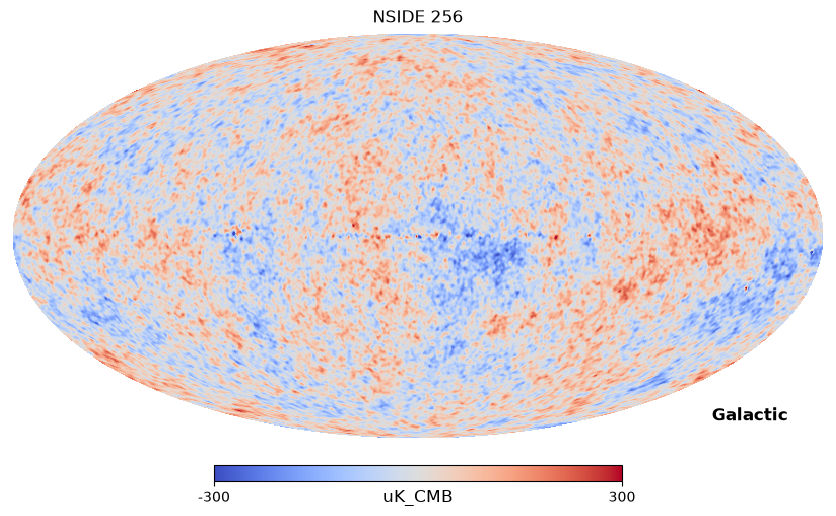

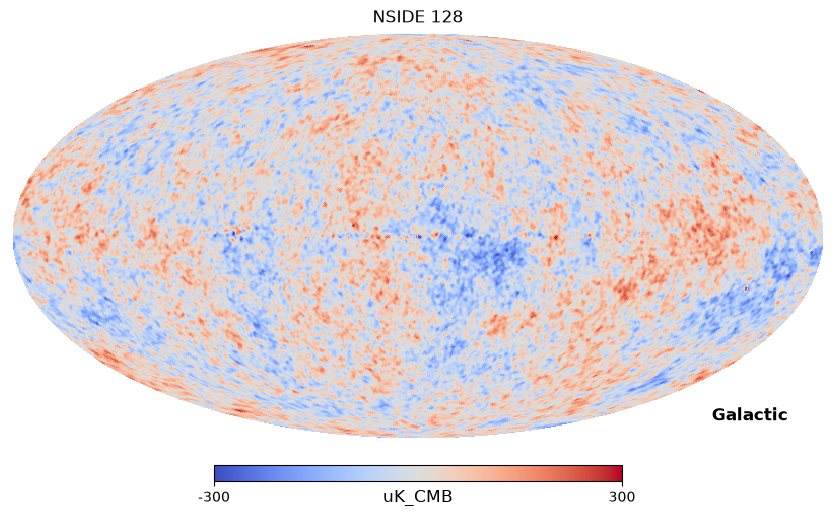

In [8]:
hp.mollview(mapa_uK, coord="G", min=-300, max=300, cmap="coolwarm",
            title=f"NSIDE {nside}", unit="uK_CMB")
plt.show()

hp.mollview(mapa_baixo, coord="G", min=-300, max=300, cmap="coolwarm",
            title=f"NSIDE {NSIDE_ALVO}", unit="uK_CMB")
plt.show()

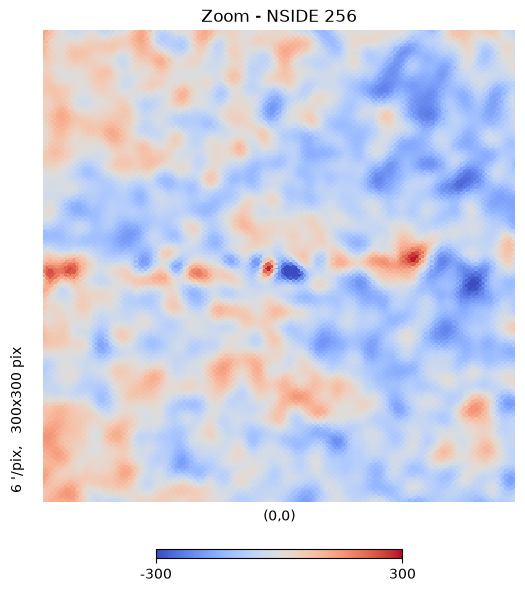

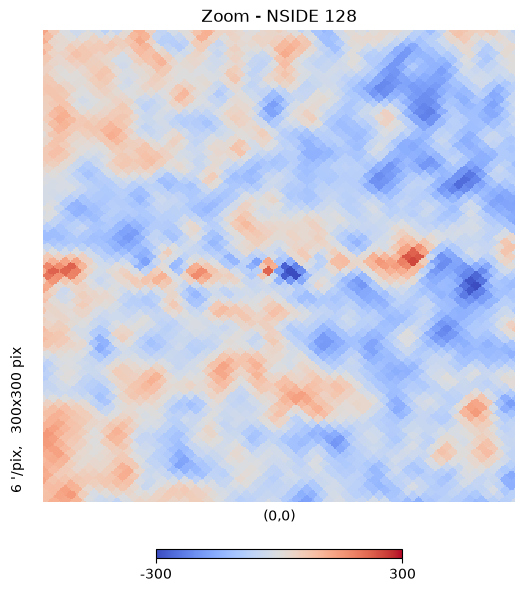

In [9]:
l_zoom, b_zoom = 0.0, 0.0  # direcao do centro galactico

hp.gnomview(mapa_uK, rot=[l_zoom, b_zoom], xsize=300, reso=6, min=-300, max=300,
            cmap="coolwarm", title=f"Zoom - NSIDE {nside}")
plt.show()

hp.gnomview(mapa_baixo, rot=[l_zoom, b_zoom], xsize=300, reso=6, min=-300, max=300,
            cmap="coolwarm", title=f"Zoom - NSIDE {NSIDE_ALVO}")
plt.show()

## 7. Trabalhar com o mapa degradado

A partir daqui usamos o mapa degradado, para os cálculos ficarem mais leves. Guardamos o
NSIDE e o número total de pixels correspondentes.


In [10]:
nside_trabalho = NSIDE_ALVO
npix_trabalho = hp.nside2npix(nside_trabalho)
print(f"Trabalhando com NSIDE={nside_trabalho}, Npix={npix_trabalho:,}")

Trabalhando com NSIDE=128, Npix=196,608


## 8. Relacionar pixels com direções

`hp.pix2ang` converte índice de pixel em ângulos: `theta` (colatitude) e `phi`
(longitude). A latitude galáctica é $b = 90^\circ - \theta$ (em graus, após converter).


In [11]:
pixels = np.arange(npix_trabalho)
theta, phi = hp.pix2ang(nside_trabalho, pixels)

b_lat = 90.0 - np.degrees(theta)  # latitude galactica, em graus
l_lon = np.degrees(phi)           # longitude galactica, em graus

print(f"b varia de {b_lat.min():.1f}° a {b_lat.max():.1f}° (esperado: ~-90 a +90)")

b varia de -89.6° a 89.6° (esperado: ~-90 a +90)


## 9. Construir o corte galáctico

Adotamos inicialmente $|b| < 20°$. O array booleano é `True` para os pixels da região a
excluir (plano galáctico) e `False` para os pixels mantidos. Ver vários `False` no início
não indica erro — a máscara tem um valor para cada pixel, em qualquer ordem.


In [12]:
CORTE_GRAUS = 20
mask_excluir = np.abs(b_lat) < CORTE_GRAUS

print(f"Primeiros 10 valores da mascara: {mask_excluir[:10]}")

Primeiros 10 valores da mascara: [False False False False False False False False False False]


## 10. Conferir a máscara

Conta quantos elementos são `True`, confere o tamanho do array e compara com o número de
pixels do mapa — uma máscara válida tem exatamente um valor booleano por pixel.


In [13]:
n_excluidos = mask_excluir.sum()
print(f"Pixels excluidos (|b| < {CORTE_GRAUS}°): {n_excluidos:,}")
print(f"Tamanho da mascara: {len(mask_excluir):,}")
print(f"Numero de pixels do mapa: {npix_trabalho:,}")
assert len(mask_excluir) == npix_trabalho

Pixels excluidos (|b| < 20°): 67,072
Tamanho da mascara: 196,608
Numero de pixels do mapa: 196,608


## 11. Aplicar a máscara

Copia o mapa e atribui `hp.UNSEEN` aos pixels selecionados pelo corte. **Não** apagamos
elementos do vetor — isso destruiria a correspondência entre índice HEALPix e posição no
céu; o array continua com o mesmo tamanho, só os valores mudam.


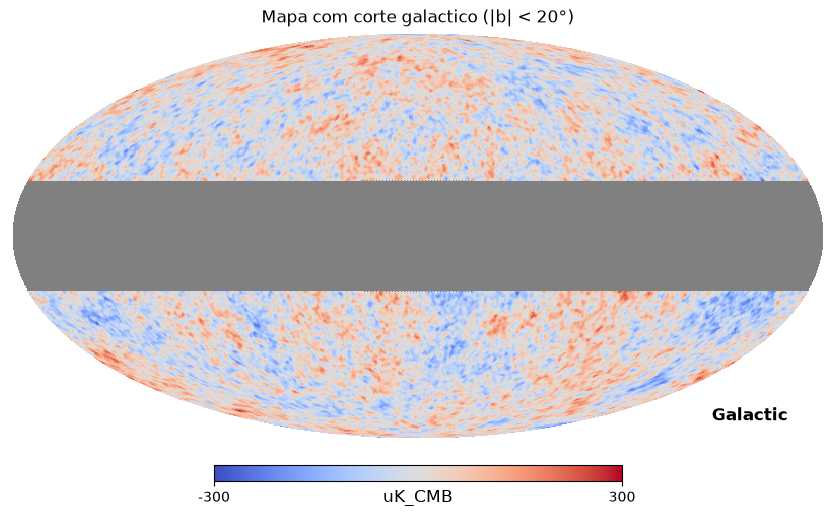

In [14]:
mapa_mask = mapa_baixo.copy()
mapa_mask[mask_excluir] = hp.UNSEEN

hp.mollview(
    mapa_mask,
    coord="G",
    min=-300,
    max=300,
    cmap="coolwarm",
    title=f"Mapa com corte galactico (|b| < {CORTE_GRAUS}°)",
    unit="uK_CMB",
)
plt.show()

## 12. Visualizar a máscara

Mapa binário: **1 para pixels mantidos**, **0 para pixels excluídos**. Visualizado
separadamente do mapa físico de temperatura, para não confundir os dois.


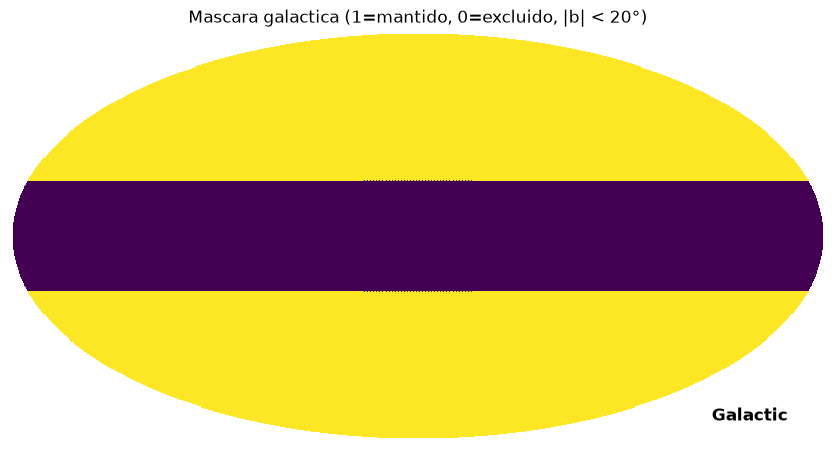

In [15]:
mapa_binario = (~mask_excluir).astype(int)  # 1 = mantido, 0 = excluido

hp.mollview(
    mapa_binario,
    coord="G",
    cmap="viridis",
    title=f"Mascara galactica (1=mantido, 0=excluido, |b| < {CORTE_GRAUS}°)",
    cbar=False,
)
plt.show()

## 13. Calcular f_sky

$$f_{sky} = \frac{N_{pixels\ utilizados}}{N_{pixels\ totais}}$$


In [16]:
f_sky_20 = (~mask_excluir).sum() / npix_trabalho
print(f"f_sky para |b| < {CORTE_GRAUS}°: {f_sky_20:.2f}")

f_sky para |b| < 20°: 0.66


## 14. Comparar cortes

Repete para $|b| < 10°, 20°$ e $30°$: para cada corte, visualiza o mapa e calcula
`f_sky`. Quanto maior o corte, mais céu é removido perto da Galáxia — mas menos céu sobra
para a análise.


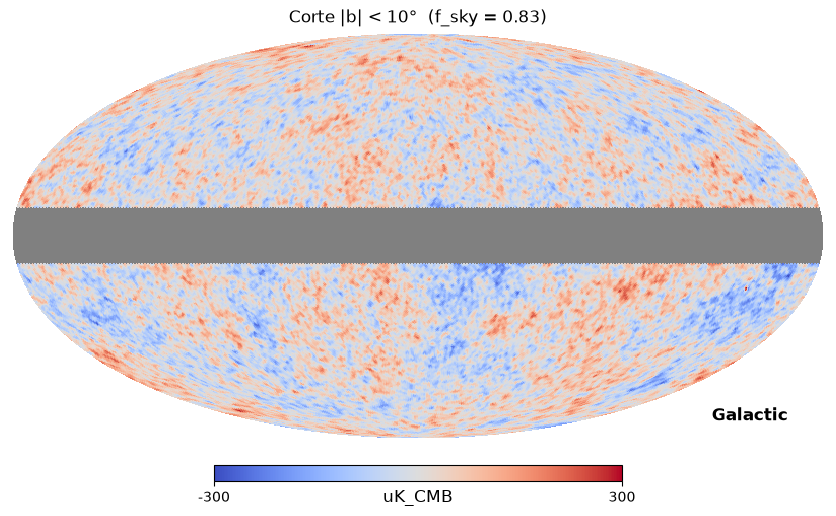

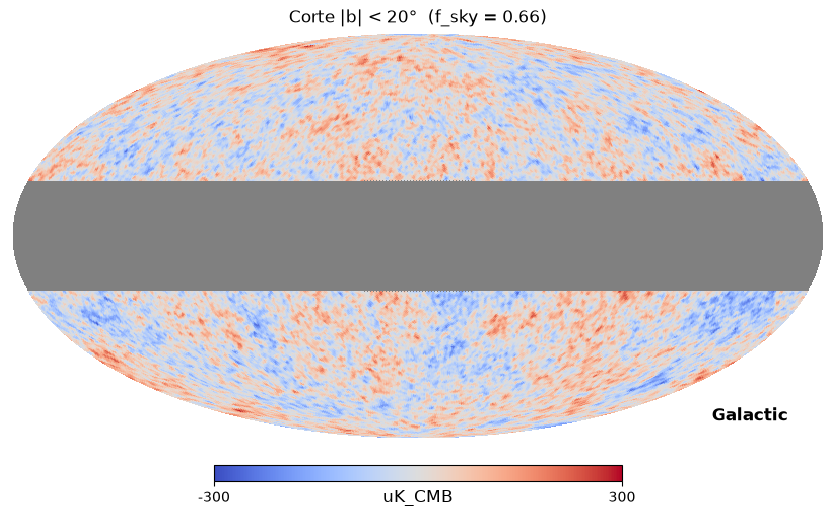

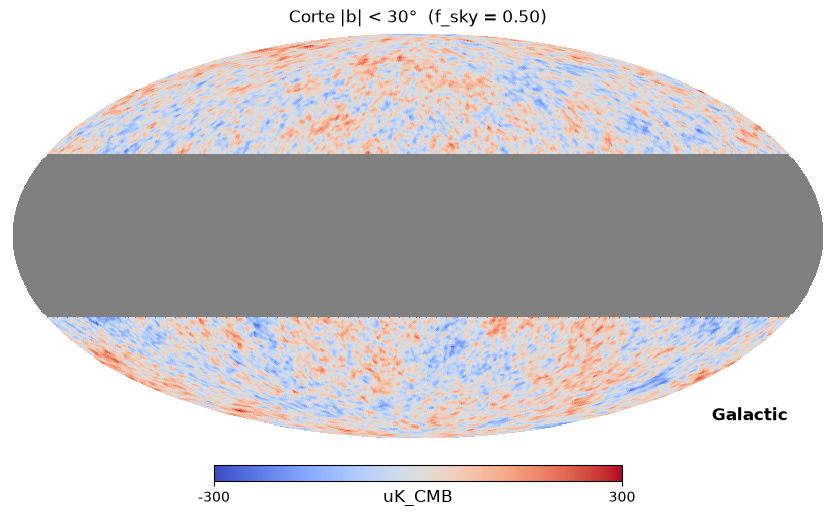

Corte     Regra          f_sky
10°        |b| < 10°       0.83
20°        |b| < 20°       0.66
30°        |b| < 30°       0.50


In [17]:
resultados = []
for corte in (10, 20, 30):
    mask = np.abs(b_lat) < corte
    f_sky = (~mask).sum() / npix_trabalho
    resultados.append((corte, f_sky))

    mapa_corte = mapa_baixo.copy()
    mapa_corte[mask] = hp.UNSEEN
    hp.mollview(mapa_corte, coord="G", min=-300, max=300, cmap="coolwarm",
                title=f"Corte |b| < {corte}°  (f_sky = {f_sky:.2f})", unit="uK_CMB")
    plt.show()

print(f"{'Corte':<10}{'Regra':<15}{'f_sky'}")
for corte, f_sky in resultados:
    print(f"{corte}°{'':<8}|b| < {corte}°{'':<7}{f_sky:.2f}")

## 15. Próximo passo

**Não usamos `anafast` nesta aula.** Uma máscara modifica a relação entre os multipolos
$\ell$ — o espectro de potência obtido de um céu incompleto (mascarado) precisa de um
tratamento próprio (deconvolução da máscara, ex. MASTER/NaMaster) para não introduzir
vazamento espectral (*leakage*) entre multipolos. Isso será abordado em uma aula futura.


## Bônus: sintetizar um mapa a partir do espectro observado (D_l -> C_l)

Até agora usamos um mapa real pronto. Aqui fazemos o caminho inverso: partimos do
**espectro de potência observado** pelo Planck (a mesma tabela `D_l` usada no app
"dados reais" deste repositório) e reconstruímos um mapa sintetizado com `hp.synfast`.

A relação entre o espectro $D_\ell$ (o que é medido/tabelado) e $C_\ell$ (o que
`hp.synfast` espera) é:

$$D_\ell = \frac{\ell(\ell+1)}{2\pi} C_\ell \quad\Longrightarrow\quad
C_\ell = \frac{2\pi\, D_\ell}{\ell(\ell+1)}$$


In [18]:
ARQUIVO_ESPECTRO = os.path.join(CAMINHO_REPO_DADOS, "planck2018_TT_full_R3.01.txt")

dados_espectro = np.loadtxt(ARQUIVO_ESPECTRO)
ell = dados_espectro[:, 0].astype(int)
dl = dados_espectro[:, 1]  # D_l observado, em uK^2

print(f"ell vai de {ell.min()} a {ell.max()} ({len(ell)} pontos)")
print(f"dl (D_l): min={dl.min():.1f}, max={dl.max():.1f} uK^2")

ell vai de 2 a 2508 (2507 pontos)
dl (D_l): min=-152.2, max=6651.8 uK^2


Convertendo $D_\ell \to C_\ell$ (evitando divisão por zero em $\ell=0,1$) e
truncando valores negativos: $D_\ell$ observado tem ruído instrumental e pode ficar
negativo em $\ell$ alto (33 dos 2507 pontos deste arquivo) — como $C_\ell$ é uma
variância, não pode ser negativo, então zeramos esses pontos antes de gerar o mapa.


In [19]:
cl_recuperado = np.zeros_like(dl)
cl_recuperado[2:] = dl[2:] * (2 * np.pi) / (ell[2:] * (ell[2:] + 1))

n_negativos = (cl_recuperado < 0).sum()
print(f"Valores negativos de C_l (ruido observacional): {n_negativos}")

cl_recuperado = np.clip(cl_recuperado, 0, None)

Valores negativos de C_l (ruido observacional): 33


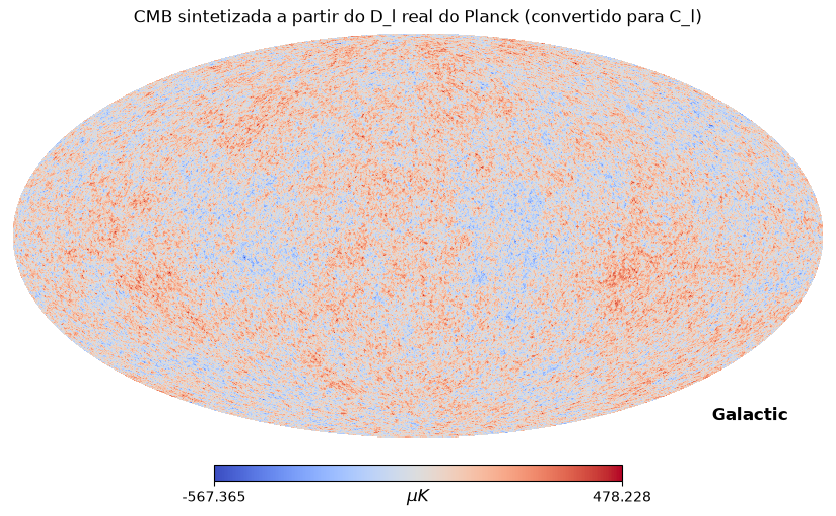

In [20]:
NSIDE_SINTESE = 256  # 512 tambem funciona, mas fica mais lento nesta demonstracao

np.random.seed(42)
mapa_cmb = hp.synfast(cl_recuperado, nside=NSIDE_SINTESE, lmax=len(dl) - 1, new=True)

hp.mollview(
    mapa_cmb,
    coord="G",
    title="CMB sintetizada a partir do D_l real do Planck (convertido para C_l)",
    unit=r"$\mu K$",
    cmap="coolwarm",
)
plt.show()

Esse mapa **não é** o céu real fotografado pelo Planck — é uma *realização*
aleatória que tem o mesmo espectro de potência que o Planck mediu de verdade. Mudar o
`seed` gera outra realização igualmente válida do mesmo espectro (variância cósmica).


## Entregáveis desta aula

- Mapa original visualizado
- NSIDE e N_pix originais
- Mapa degradado (NSIDE menor)
- Comparação das resoluções (mollview + gnomview)
- Latitude galáctica dos pixels (`hp.pix2ang`)
- Máscara de 20°
- Mapa binário da máscara
- `f_sky` para o corte de 20°
- Comparação dos cortes de 10°, 20° e 30°

**Referências:**
- Planck Legacy Archive — https://pla.esac.esa.int
- NASA LAMBDA (WMAP) — https://lambda.gsfc.nasa.gov
- healpy documentation — https://healpy.readthedocs.io
